In [19]:
import pandas as pd
import os
from scipy import stats  
import matplotlib.pyplot as plt
import numpy as np

In [20]:
data = pd.read_csv('project_data/full_dataset.csv')

/var/folders/7d/2d_kq54s00v0272gkndgzxd80000gn/T/ipykernel_5569/3864665399.py:1: DtypeWarning: Columns (27,28,29,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('project_data/full_dataset.csv')


In [21]:
data = data.loc[data['group_depression'] | data['group_anxiety']]

# Simple comparisons

In [22]:
OUTCOME_VAR = 'VADER_NEG'

## Mean vs median

TtestResult(statistic=np.float64(106.67597248808671), pvalue=np.float64(0.0), df=np.int64(1301))


Text(0.5, 1.0, 'Distribution of difference between mean and median VADER NA scores for raw data')

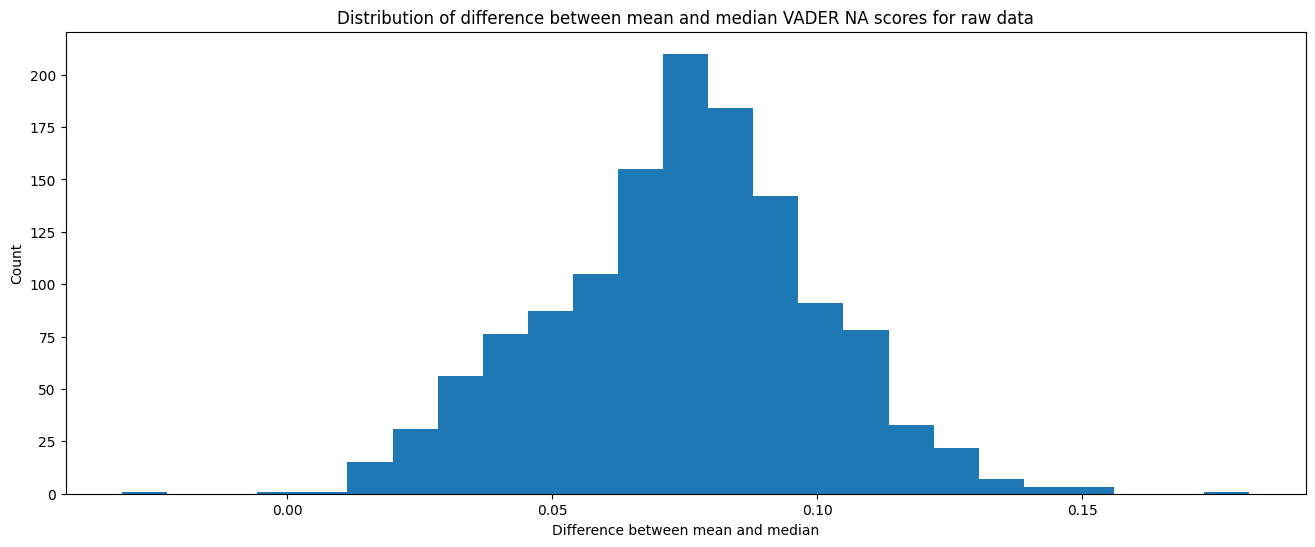

In [23]:
df = data.groupby('user_id').agg({
    OUTCOME_VAR: ['mean', 'median'],
})

print(stats.ttest_rel(
    df[(OUTCOME_VAR, 'mean')],
    df[(OUTCOME_VAR, 'median')]
))

fig, ax = plt.subplots(figsize=(16, 6))
ax.hist(
    df[(OUTCOME_VAR, 'mean')] - df[(OUTCOME_VAR, 'median')],
    bins=25,
)
ax.set_xlabel('Difference between mean and median')
ax.set_ylabel('Count')
ax.set_title('Distribution of difference between mean and median VADER NA scores for raw data')

## NA levels

In [24]:
data_aggregated_level = data.groupby('user_id').agg({
    OUTCOME_VAR: 'mean',
    'group_anxiety': 'first',
    'group_depression': 'first'
}).dropna()

stats.mannwhitneyu(
    data_aggregated_level.loc[data_aggregated_level.group_depression][OUTCOME_VAR],
    data_aggregated_level.loc[data_aggregated_level.group_anxiety][OUTCOME_VAR])

MannwhitneyuResult(statistic=np.float64(227445.0), pvalue=np.float64(1.8312182790774562e-05))

In [25]:
data_aggregated_level.groupby('group_depression').mean(numeric_only=True)

,VADER_NEG
group_depression,
False,0.081877
True,0.087820


## variability

In [26]:
data_aggregated_spread = data.groupby('user_id').agg({
    OUTCOME_VAR: 'std',
    'group_anxiety': 'first',
    'group_depression': 'first'
}).dropna()

stats.mannwhitneyu(
    data_aggregated_spread.loc[data_aggregated_spread.group_depression][OUTCOME_VAR],
    data_aggregated_spread.loc[data_aggregated_spread.group_anxiety][OUTCOME_VAR])

MannwhitneyuResult(statistic=np.float64(237172.0), pvalue=np.float64(6.382384167585887e-09))

In [27]:
data_aggregated_spread.groupby('group_depression').mean(numeric_only=True)

,VADER_NEG
group_depression,
False,0.127589
True,0.135634


## Plot mean and SD

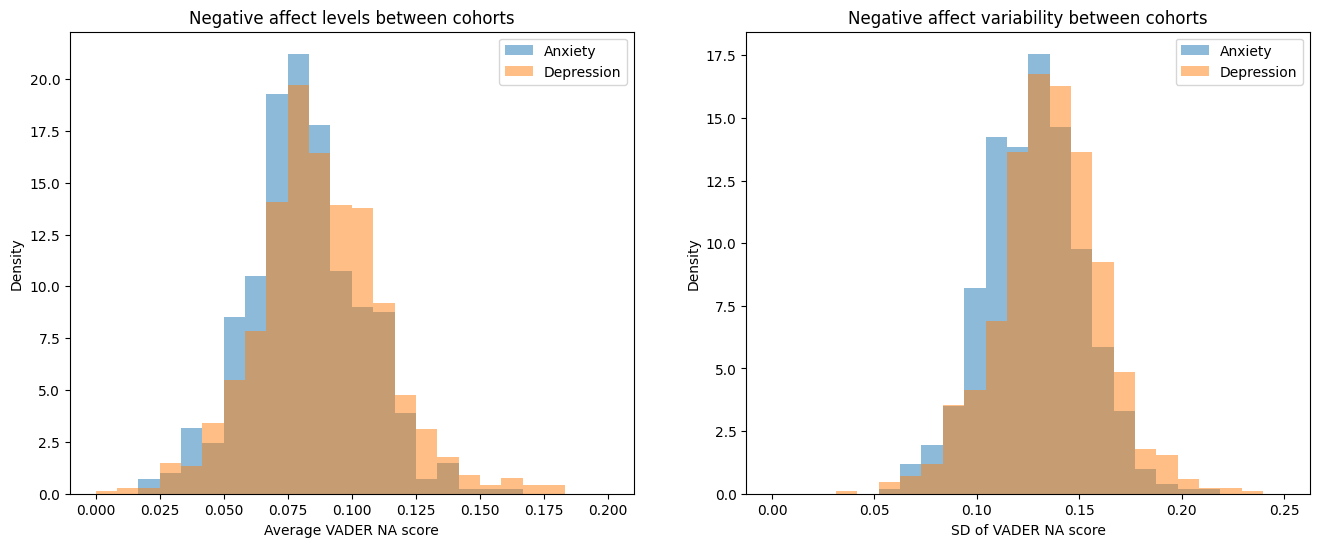

In [28]:
fig,ax = plt.subplots(1,2,figsize=(16,6))

bins = np.linspace(0, 0.2, 25)

ax[0].hist(data_aggregated_level.loc[data_aggregated_level.group_anxiety]['VADER_NEG'], alpha = 0.5, density=True, bins=bins, label='Anxiety')
ax[0].hist(data_aggregated_level.loc[data_aggregated_level.group_depression]['VADER_NEG'], alpha = 0.5, density=True, bins=bins, label='Depression')
ax[0].set_title('Negative affect levels between cohorts')
ax[0].set_xlabel('Average VADER NA score')
ax[0].set_ylabel('Density')
ax[0].legend()

bins = np.linspace(0, 0.25, 25)

ax[1].hist(data_aggregated_spread.loc[data_aggregated_spread.group_anxiety]['VADER_NEG'], alpha = 0.5, density=True, bins=bins, label='Anxiety')
ax[1].hist(data_aggregated_spread.loc[data_aggregated_spread.group_depression]['VADER_NEG'], alpha = 0.5, density=True, bins=bins, label='Depression')
ax[1].set_title('Negative affect variability between cohorts')
ax[1].set_xlabel('SD of VADER NA score')
ax[1].set_ylabel('Density')
ax[1].legend()

plt.savefig('figures/na_histograms_overall.png', dpi=400, bbox_inches='tight')

## 6-hour-window

In [29]:
windowed_data = pd.read_csv('project_data/windowed_mean_data.csv', index_col=0)
windowed_data = windowed_data.loc[windowed_data['group_depression'] + windowed_data['group_anxiety'] > 0]

In [30]:
windowed_data

,user_id,created_at,VADER_NEG,group_anxiety,group_depression,comorbid,gender_female,19-29,30-39,<=18,>=40,day_of_week,gender
0,uANX001,2020-03-24 18:43:59+00:00,0.158000,1.0,0.0,0.0,1.0,0.4307,0.5255,0.0120,0.0318,1.0,female
1,uANX001,2020-03-24 20:36:27+00:00,0.122417,1.0,0.0,0.0,1.0,0.4307,0.5255,0.0120,0.0318,1.0,female
2,uANX001,2020-03-24 21:20:58+00:00,0.134071,1.0,0.0,0.0,1.0,0.4307,0.5255,0.0120,0.0318,1.0,female
3,uANX001,2020-03-24 21:22:19+00:00,0.134071,1.0,0.0,0.0,1.0,0.4307,0.5255,0.0120,0.0318,1.0,female
4,uANX001,2020-03-24 21:22:50+00:00,0.134071,1.0,0.0,0.0,1.0,0.4307,0.5255,0.0120,0.0318,1.0,female
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1840294,uSAD005,2020-04-30 07:42:28+00:00,0.092000,0.0,1.0,0.0,1.0,0.1901,0.7681,0.0062,0.0356,3.0,female
1840295,uSAD005,2020-04-30 07:42:59+00:00,0.092000,0.0,1.0,0.0,1.0,0.1901,0.7681,0.0062,0.0356,3.0,female
1840296,uSAD005,2020-04-30 07:46:32+00:00,0.092000,0.0,1.0,0.0,1.0,0.1901,0.7681,0.0062,0.0356,3.0,female
1840297,uSAD005,2020-04-30 16:16:10+00:00,0.121500,0.0,1.0,0.0,1.0,0.1901,0.7681,0.0062,0.0356,3.0,female


## Means vs median

TtestResult(statistic=np.float64(32.71701862986569), pvalue=np.float64(1.0252309907608484e-171), df=np.int64(1298))


Text(0.5, 1.0, 'Distribution of difference between mean and median VADER NA scores for 6-hour windowed data')

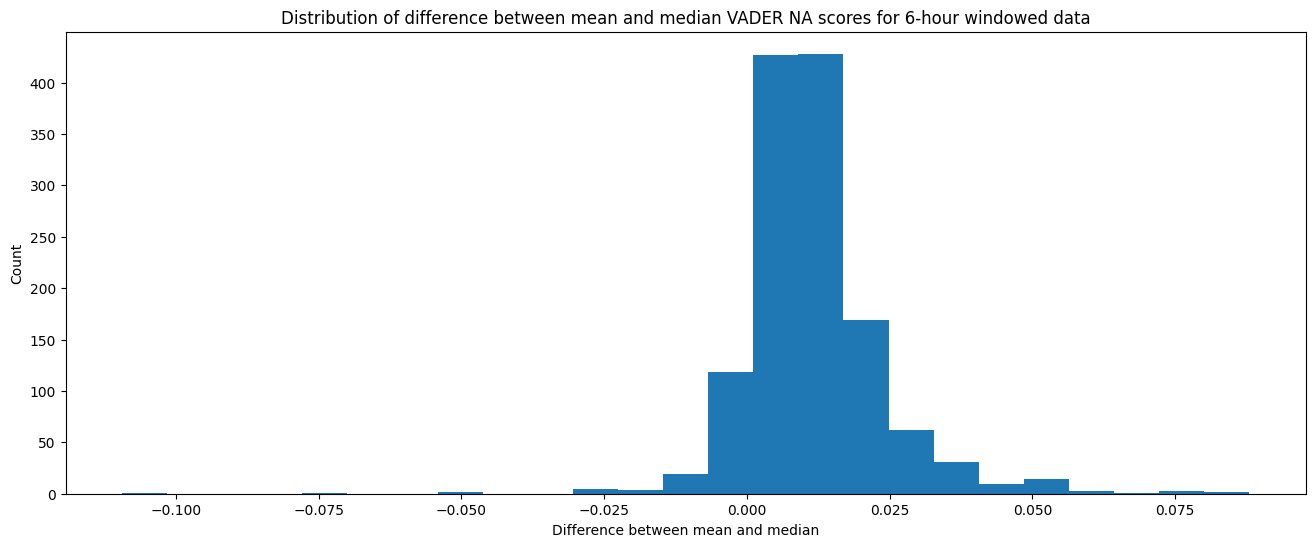

In [31]:
df = windowed_data.groupby('user_id').agg({
    OUTCOME_VAR: ['mean', 'median'],
})

print(stats.ttest_rel(
    df[(OUTCOME_VAR, 'mean')],
    df[(OUTCOME_VAR, 'median')]
))

fig, ax = plt.subplots(figsize=(16, 6))
ax.hist(
    df[(OUTCOME_VAR, 'mean')] - df[(OUTCOME_VAR, 'median')],
    bins=25,
)
ax.set_xlabel('Difference between mean and median')
ax.set_ylabel('Count')
ax.set_title('Distribution of difference between mean and median VADER NA scores for 6-hour windowed data')

### Standard deviation

In [32]:
data_aggregated_spread = windowed_data.groupby('user_id').agg({
    OUTCOME_VAR: 'std',
    'group_anxiety': 'first',
    'group_depression': 'first'
}).dropna().reset_index()

stats.mannwhitneyu(
    data_aggregated_spread.loc[data_aggregated_spread.group_depression][OUTCOME_VAR],
    data_aggregated_spread.loc[data_aggregated_spread.group_anxiety][OUTCOME_VAR])

MannwhitneyuResult(statistic=np.float64(1050891.0), pvalue=np.float64(6.213161301876633e-36))

In [33]:
data_aggregated_spread.groupby('group_depression').mean(numeric_only=True)

,VADER_NEG,group_anxiety
group_depression,,
0.0,0.064804,1.0
1.0,0.069277,0.0


## Inspect speific user distribution

In [34]:
data_aggregated = windowed_data.reset_index().dropna()

array([[<Axes: title={'center': 'VADER_NEG'}>]], dtype=object)

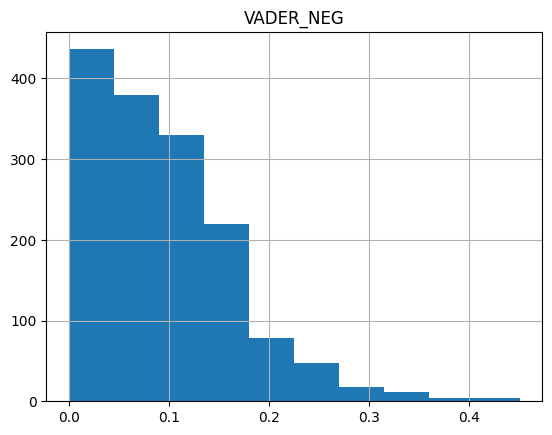

In [35]:
data_aggregated.loc[data_aggregated.user_id == data_aggregated.user_id.sample(1).item()].hist(OUTCOME_VAR)

## Difference between means and medians

MannwhitneyuResult(statistic=np.float64(1052750.5), pvalue=np.float64(7.821029885172804e-28))

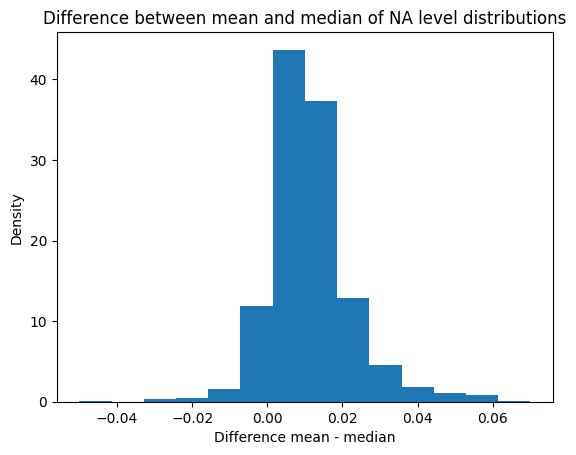

In [36]:
means = data_aggregated[['user_id', OUTCOME_VAR]].groupby('user_id').mean()
medians = data_aggregated[['user_id', OUTCOME_VAR]].groupby('user_id').median()

#(means-medians).hist()

plt.hist(means-medians, bins = np.linspace(-0.05, 0.07,15), density=True)
plt.title('Difference between mean and median of NA level distributions')
plt.ylabel('Density')
plt.xlabel('Difference mean - median')


stats.mannwhitneyu(
    means[OUTCOME_VAR],
    medians[OUTCOME_VAR])

## General valence

In [37]:
data_agregated_level = windowed_data.groupby('user_id').agg({
    OUTCOME_VAR: 'mean',
    'group_anxiety': 'first',
    'group_depression': 'first'
}).dropna().reset_index()

stats.mannwhitneyu(
    data_agregated_level.loc[data_agregated_level.group_depression][OUTCOME_VAR],
    data_agregated_level.loc[data_agregated_level.group_anxiety][OUTCOME_VAR])

MannwhitneyuResult(statistic=np.float64(636510.0), pvalue=np.float64(6.213161301876633e-36))

In [38]:
data_agregated_level.groupby('group_depression').mean(numeric_only=True)

,VADER_NEG,group_anxiety
group_depression,,
0.0,0.082254,1.0
1.0,0.088136,0.0


## Difference between means and medians

MannwhitneyuResult(statistic=np.float64(1052750.5), pvalue=np.float64(7.821029885172804e-28))

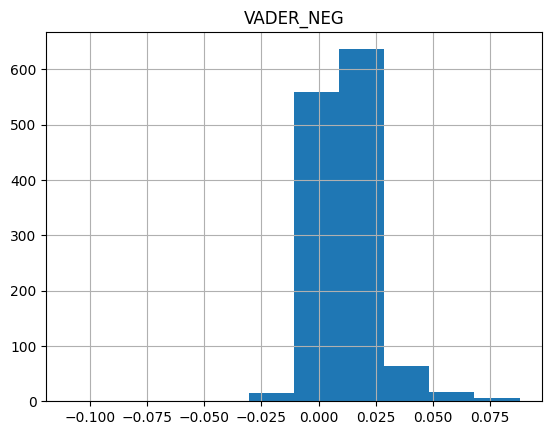

In [39]:
means = data_aggregated[['user_id', OUTCOME_VAR]].groupby('user_id').mean()
medians = data_aggregated[['user_id', OUTCOME_VAR]].groupby('user_id').median()

(means-medians).hist()
from scipy import stats  
stats.mannwhitneyu(
    means[OUTCOME_VAR],
    medians[OUTCOME_VAR])

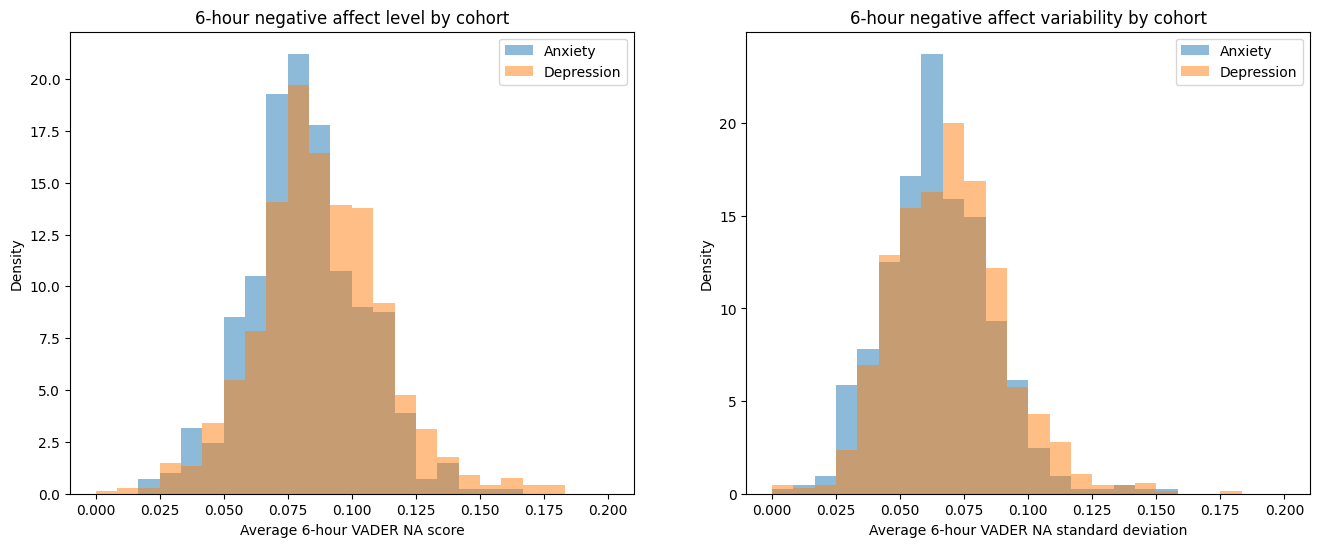

In [40]:
bins = np.linspace(0, 0.2,25)

fig,ax = plt.subplots(1,2,figsize=(16,6))

ax[0].hist(data_aggregated_level.loc[data_aggregated_level.group_anxiety == 1][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Anxiety')
ax[0].hist(data_aggregated_level.loc[data_aggregated_level.group_depression == 1][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Depression')
ax[0].legend()
ax[0].set_title('6-hour negative affect level by cohort')
ax[0].set_ylabel('Density')
ax[0].set_xlabel('Average 6-hour VADER NA score')

bins = np.linspace(0, 0.2,25)

ax[1].hist(data_aggregated_spread.loc[data_aggregated_spread.group_anxiety == 1][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Anxiety')
ax[1].hist(data_aggregated_spread.loc[data_aggregated_spread.group_depression == 1][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Depression')
ax[1].legend()
ax[1].set_title('6-hour negative affect variability by cohort')
ax[1].set_ylabel('Density')
ax[1].set_xlabel('Average 6-hour VADER NA standard deviation')

plt.savefig('figures/na_histograms_6hr.png', dpi=400, bbox_inches='tight')

## Daily affect level

In [41]:
daily_data = pd.read_csv('project_data/daily_mean_data.csv', index_col=0)
daily_data = daily_data.loc[daily_data['group_depression'] + daily_data['group_anxiety'] > 0]

## Means vs medians

TtestResult(statistic=np.float64(37.165165990145354), pvalue=np.float64(1.2223084917829922e-206), df=np.int64(1301))


Text(0.5, 1.0, 'Distribution of difference between mean and median VADER NA scores for daily data')

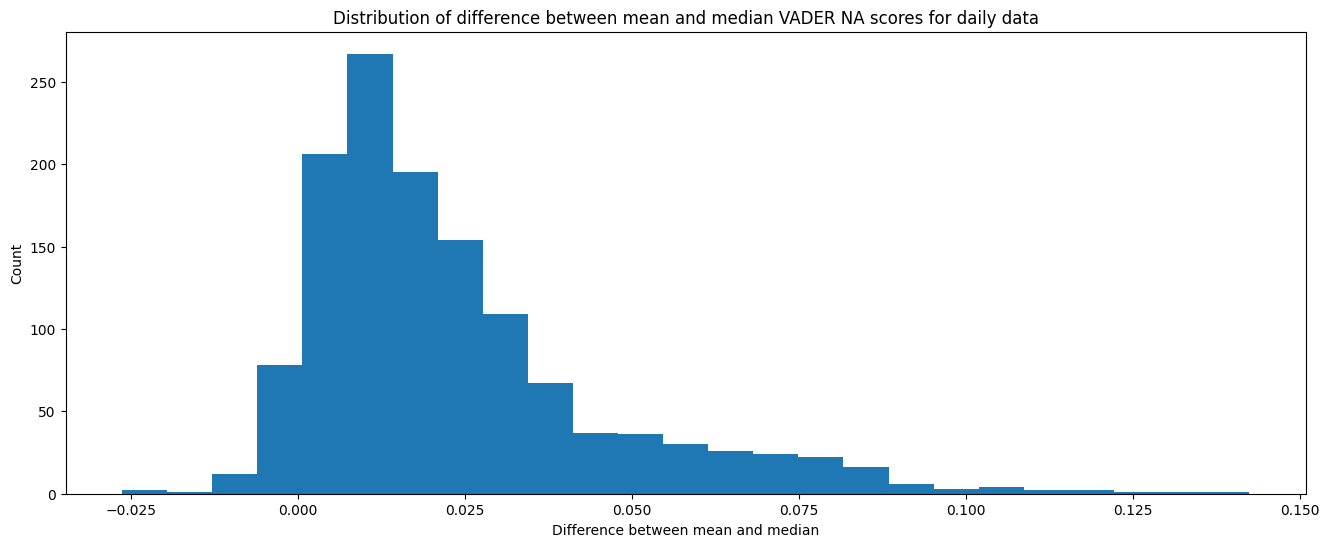

In [42]:
df = daily_data.groupby('user_id').agg({
    OUTCOME_VAR: ['mean', 'median'],
})

print(stats.ttest_rel(
    df[(OUTCOME_VAR, 'mean')],
    df[(OUTCOME_VAR, 'median')]
))

fig, ax = plt.subplots(figsize=(16, 6))
ax.hist(
    df[(OUTCOME_VAR, 'mean')] - df[(OUTCOME_VAR, 'median')],
    bins=25,
)
ax.set_xlabel('Difference between mean and median')
ax.set_ylabel('Count')
ax.set_title('Distribution of difference between mean and median VADER NA scores for daily data')

## NA levels

In [43]:
data_aggregated_level = daily_data.groupby('user_id').agg({
    OUTCOME_VAR: 'mean',
    'group_anxiety': 'first',
    'group_depression': 'first'
}).dropna().reset_index()

stats.mannwhitneyu(
    data_aggregated_level.loc[data_aggregated_level.group_depression == 1][OUTCOME_VAR],
    data_aggregated_level.loc[data_aggregated_level.group_anxiety == 1][OUTCOME_VAR])

MannwhitneyuResult(statistic=np.float64(222435.0), pvalue=np.float64(0.0004268078160213083))

In [44]:
data_aggregated_level.groupby('group_depression').mean(numeric_only=True)

,VADER_NEG,group_anxiety
group_depression,,
False,0.082159,1.0
True,0.087281,0.0


## Means vs medians

In [45]:
means = data_aggregated_level[['user_id', OUTCOME_VAR]].groupby('user_id').mean()
medians = data_aggregated_level[['user_id', OUTCOME_VAR]].groupby('user_id').median()


stats.mannwhitneyu(
    means[OUTCOME_VAR],
    medians[OUTCOME_VAR])

MannwhitneyuResult(statistic=np.float64(847602.0), pvalue=np.float64(1.0))

## Daily affect variability

In [46]:
data_aggregated_spread = daily_data.groupby('user_id').agg({
    OUTCOME_VAR: 'std',
    'group_anxiety': 'first',
    'group_depression': 'first'
}).dropna().reset_index()

stats.mannwhitneyu(
    data_aggregated_spread.loc[data_aggregated_spread.group_depression == 1][OUTCOME_VAR],
    data_aggregated_spread.loc[data_aggregated_spread.group_anxiety == 1][OUTCOME_VAR])

MannwhitneyuResult(statistic=np.float64(224679.0), pvalue=np.float64(5.9721096657341046e-05))

In [47]:
data_aggregated_spread.groupby('group_depression').mean(numeric_only=True)

,VADER_NEG,group_anxiety
group_depression,,
False,0.080913,1.0
True,0.088507,0.0


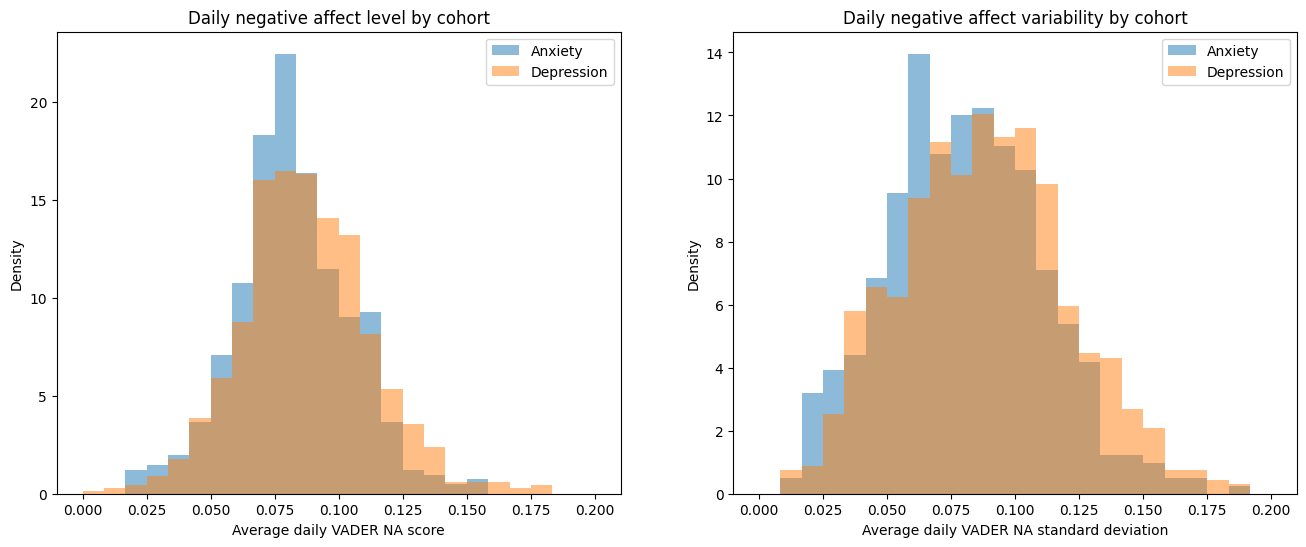

In [48]:
bins = np.linspace(0, 0.2,25)

fig,ax = plt.subplots(1,2,figsize=(16,6))

ax[0].hist(data_aggregated_level.loc[data_aggregated_level.group_anxiety][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Anxiety')
ax[0].hist(data_aggregated_level.loc[data_aggregated_level.group_depression][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Depression')
ax[0].legend()
ax[0].set_title('Daily negative affect level by cohort')
ax[0].set_ylabel('Density')
ax[0].set_xlabel('Average daily VADER NA score')

bins = np.linspace(0, 0.2,25)

ax[1].hist(data_aggregated_spread.loc[data_aggregated_spread.group_anxiety == 1][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Anxiety')
ax[1].hist(data_aggregated_spread.loc[data_aggregated_spread.group_depression == 1][OUTCOME_VAR], alpha  =0.5, bins = bins, density=True, label='Depression')
ax[1].legend()
ax[1].set_title('Daily negative affect variability by cohort')
ax[1].set_ylabel('Density')
ax[1].set_xlabel('Average daily VADER NA standard deviation')

plt.savefig('figures/na_histograms_daily.png', dpi=400, bbox_inches='tight')